## Learning goals

We will use only two features so every equation can be seen as a line. By the end, you should be able to:

- read $\mathbf{w}^\top\mathbf{x}+b=0$ as a decision line;
- combine the two class conditions into $y_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1$;
- explain why rescaling $\mathbf{w}$ and $b$ does not move the decision line;
- derive the perpendicular distance between parallel hyperplanes; and
- derive the full SVM margin $2/\lVert\mathbf{w}\rVert$.

This notebook supplies the geometry needed before the optimization in the next SVM lesson.

## 1. A concrete two-feature example

Each observation has two features, so

$$
\mathbf{x}_i=\begin{pmatrix}x_{i1}\\x_{i2}\end{pmatrix},
\qquad y_i\in\{-1,+1\}.
$$

Choose

$$
\mathbf{w}=\begin{pmatrix}1\\1\end{pmatrix},
\qquad b=-5.
$$

The unthresholded score is

$$
g(\mathbf{x})=\mathbf{w}^\top\mathbf{x}+b=x_1+x_2-5.
$$

The classifier predicts $+1$ when $g(\mathbf{x})>0$ and $-1$ when $g(\mathbf{x})<0$. The code creates points on both sides, including four points exactly on the future margin lines.

In [1]:
#| label: setup-data

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    [1.0, 1.5], [2.0, 1.0], [1.0, 3.0], [2.0, 2.0],  # y = -1
    [2.0, 4.0], [4.0, 2.0], [4.0, 3.0], [3.5, 3.5],  # y = +1
])
y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

w = np.array([1.0, 1.0])
b = -5.0
scores = X @ w + b
predictions = np.sign(scores).astype(int)

print('w =', w, '  b =', b)
print('scores =', scores)
print('predictions =', predictions)

w = [1. 1.]   b = -5.0
scores = [-2.5 -2.  -1.  -1.   1.   1.   2.   2. ]
predictions = [-1 -1 -1 -1  1  1  1  1]


## 2. One decision line and two margin lines

The decision boundary is the set of points whose score is zero:

$$
\mathbf{w}^\top\mathbf{x}+b=0.
$$

With two features and $w_2\neq0$, solve for the vertical coordinate:

$$
w_1x_1+w_2x_2+b=c
\quad\Longrightarrow\quad
x_2=-\frac{w_1}{w_2}x_1+\frac{c-b}{w_2}.
$$

Setting $c=0,+1,-1$ gives three parallel lines. In our example they are

$$
x_2=-x_1+5,\qquad x_2=-x_1+6,\qquad x_2=-x_1+4.
$$

All have slope $-1$ because all share the same normal vector $\mathbf{w}=(1,1)^\top$. The next cell draws the data, the decision boundary, and both margin lines.

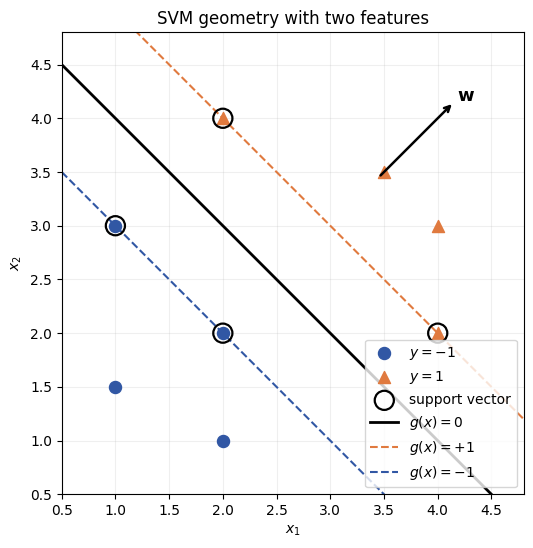

In [2]:
#| label: fig-three-hyperplanes
#| fig-cap: "The decision boundary and the two canonical margin lines in a two-feature space. Circled points are support vectors."

x1_grid = np.linspace(0.5, 4.8, 300)
line = lambda c: (c - b - w[0] * x1_grid) / w[1]
support = np.isclose(y * scores, 1.0)

fig, ax = plt.subplots(figsize=(7, 6))
for label, color, marker in [(-1, '#3157a4', 'o'), (1, '#e07a3f', '^')]:
    points = X[y == label]
    ax.scatter(points[:, 0], points[:, 1], s=75, c=color, marker=marker,
               label=f'$y={label}$', zorder=3)
ax.scatter(X[support, 0], X[support, 1], s=190, facecolors='none',
           edgecolors='black', linewidths=1.6, label='support vector', zorder=4)
ax.plot(x1_grid, line(0), color='black', linewidth=2, label='$g(x)=0$')
ax.plot(x1_grid, line(1), '--', color='#e07a3f', label='$g(x)=+1$')
ax.plot(x1_grid, line(-1), '--', color='#3157a4', label='$g(x)=-1$')
ax.annotate('', xy=(4.15, 4.15), xytext=(3.45, 3.45),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
ax.text(4.18, 4.16, '$\mathbf{w}$', fontsize=13)
ax.set(xlim=(0.5, 4.8), ylim=(0.5, 4.8), xlabel='$x_1$', ylabel='$x_2$',
       title='SVM geometry with two features')
ax.set_aspect('equal')
ax.legend(loc='lower right')
ax.grid(alpha=0.2)
plt.show()

## 3. Derive the single SVM inequality

After choosing the canonical scaling, require positive observations to be on or beyond the $+1$ line:

$$
y_i=+1:\qquad \mathbf{w}^\top\mathbf{x}_i+b\geq1.
$$

Require negative observations to be on or beyond the $-1$ line:

$$
y_i=-1:\qquad \mathbf{w}^\top\mathbf{x}_i+b\leq-1.
$$

Multiply the second inequality by $-1$. Its direction reverses:

$$
-(\mathbf{w}^\top\mathbf{x}_i+b)\geq1.
$$

Because $y_i=-1$ in that case, both class-specific conditions become

$$
\boxed{y_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1}
\qquad\text{for every }i.
$$

The quantity $\widehat\gamma_i=y_i(\mathbf{w}^\top\mathbf{x}_i+b)$ is the **functional margin** of observation $i$. Equality identifies a support vector; a value greater than 1 places the observation outside the margin band. The cell evaluates every row of the inequality.

In [3]:
#| label: verify-inequality

functional_margin = y * scores
header = f"{'i':>2} {'x1':>5} {'x2':>5} {'y':>3} {'g(x)':>7} {'y g(x)':>8} {'>= 1':>6}"
print(header)
print('-' * len(header))
for i, (point, label, score, margin) in enumerate(
    zip(X, y, scores, functional_margin), start=1
):
    print(f'{i:2d} {point[0]:5.1f} {point[1]:5.1f} {label:3d} '
          f'{score:7.1f} {margin:8.1f} {str(margin >= 1):>6}')

assert np.all(functional_margin >= 1)

 i    x1    x2   y    g(x)   y g(x)   >= 1
------------------------------------------
 1   1.0   1.5  -1    -2.5      2.5   True
 2   2.0   1.0  -1    -2.0      2.0   True
 3   1.0   3.0  -1    -1.0      1.0   True
 4   2.0   2.0  -1    -1.0      1.0   True
 5   2.0   4.0   1     1.0      1.0   True
 6   4.0   2.0   1     1.0      1.0   True
 7   4.0   3.0   1     2.0      2.0   True
 8   3.5   3.5   1     2.0      2.0   True


## 4. Why are the margin levels exactly $\pm1$?

The decision boundary has a scale ambiguity. For any $a>0$,

$$
\mathbf{w}^\top\mathbf{x}+b=0
\quad\Longleftrightarrow\quad
(a\mathbf{w})^\top\mathbf{x}+ab=0.
$$

Thus $(\mathbf{w},b)$ and $(a\mathbf{w},ab)$ describe the same decision boundary and make the same predictions, but all functional margins are multiplied by $a$:

$$
y_i[(a\mathbf{w})^\top\mathbf{x}_i+ab]
=a\,y_i(\mathbf{w}^\top\mathbf{x}_i+b).
$$

For any separating boundary, choose

$$
a=\frac{1}{\min_i y_i(\mathbf{w}^\top\mathbf{x}_i+b)}.
$$

Then the closest observation has functional margin 1. This **canonical normalization** creates the convenient margin equations $g(\mathbf{x})=+1$ and $g(\mathbf{x})=-1$; the number 1 is a scaling convention, not a special physical distance.

In [4]:
#| label: verify-rescaling

scale = 3.0
w_scaled, b_scaled = scale * w, scale * b
scores_scaled = X @ w_scaled + b_scaled

print('Same predictions:', np.array_equal(np.sign(scores), np.sign(scores_scaled)))
print('Original minimum functional margin:', np.min(y * scores))
print('Scaled minimum functional margin:  ', np.min(y * scores_scaled))
print('Decision-line coefficients:', w_scaled, b_scaled)

Same predictions: True
Original minimum functional margin: 1.0
Scaled minimum functional margin:   3.0
Decision-line coefficients: [3. 3.] -15.0


## 5. Derive the point-to-hyperplane distance

The vector $\mathbf{w}$ is perpendicular to every line $\mathbf{w}^\top\mathbf{x}+b=c$. Therefore its unit normal is

$$
\widehat{\mathbf{n}}=\frac{\mathbf{w}}{\lVert\mathbf{w}\rVert}.
$$

Let $\mathbf{x}_0$ be any point and move a signed distance $d$ along the unit normal until reaching the decision boundary:

$$
\mathbf{x}_{boundary}=\mathbf{x}_0-d\frac{\mathbf{w}}{\lVert\mathbf{w}\rVert}.
$$

Substitute this point into $\mathbf{w}^\top\mathbf{x}+b=0$:

$$
0=\mathbf{w}^\top\mathbf{x}_0+b
-d\frac{\mathbf{w}^\top\mathbf{w}}{\lVert\mathbf{w}\rVert}
=\mathbf{w}^\top\mathbf{x}_0+b-d\lVert\mathbf{w}\rVert.
$$

Hence the signed distance is

$$
d=\frac{\mathbf{w}^\top\mathbf{x}_0+b}{\lVert\mathbf{w}\rVert},
$$

and the ordinary nonnegative distance is

$$
\boxed{\operatorname{dist}(\mathbf{x}_0,H_0)
=\frac{|\mathbf{w}^\top\mathbf{x}_0+b|}{\lVert\mathbf{w}\rVert}}.
$$

For a support vector, the numerator equals 1, so its distance to the decision boundary is $1/\lVert\mathbf{w}\rVert$.

In [5]:
#| label: calculate-distances

w_norm = np.linalg.norm(w)
signed_distances = scores / w_norm
geometric_margins = y * signed_distances

print('||w|| =', w_norm)
print('Signed distances to the decision line =', np.round(signed_distances, 3))
print('Smallest labelled distance =', np.min(geometric_margins))
print('Expected support-vector distance =', 1 / w_norm)

||w|| = 1.4142135623730951
Signed distances to the decision line = [-1.768 -1.414 -0.707 -0.707  0.707  0.707  1.414  1.414]
Smallest labelled distance = 0.7071067811865475
Expected support-vector distance = 0.7071067811865475


## 6. Derive the full margin width

Take $\mathbf{x}_{-}$ on the negative margin and $\mathbf{x}_{+}$ directly opposite it on the positive margin. Because their shortest connection is parallel to $\mathbf{w}$, write

$$
\mathbf{x}_{+}=\mathbf{x}_{-}+D\frac{\mathbf{w}}{\lVert\mathbf{w}\rVert},
$$

where $D$ is the distance between the two margin hyperplanes. Their defining equations are

$$
\mathbf{w}^\top\mathbf{x}_{+}+b=+1,
\qquad
\mathbf{w}^\top\mathbf{x}_{-}+b=-1.
$$

Subtract the second equation from the first and substitute the expression for $\mathbf{x}_{+}$:

$$
2=\mathbf{w}^\top(\mathbf{x}_{+}-\mathbf{x}_{-})
=\mathbf{w}^\top\left(D\frac{\mathbf{w}}{\lVert\mathbf{w}\rVert}\right)
=D\lVert\mathbf{w}\rVert.
$$

Therefore

$$
\boxed{D=\frac{2}{\lVert\mathbf{w}\rVert}}.
$$

Each side contributes $1/\lVert\mathbf{w}\rVert$. For $\mathbf{w}=(1,1)^\top$, $\lVert\mathbf{w}\rVert=\sqrt{2}$, so the full margin is $2/\sqrt{2}=\sqrt{2}$.

In [6]:
#| label: verify-margin-width

distance_to_one_side = 1 / w_norm
full_margin = 2 / w_norm

# Points on the two margin lines connected along the unit normal.
x_minus = np.array([2.0, 2.0])
x_plus = x_minus + full_margin * (w / w_norm)

print('Distance from boundary to either margin =', distance_to_one_side)
print('Full margin 2 / ||w|| =', full_margin)
print('g(x_minus) =', x_minus @ w + b)
print('g(x_plus)  =', x_plus @ w + b)
print('Direct Euclidean distance =', np.linalg.norm(x_plus - x_minus))

Distance from boundary to either margin = 0.7071067811865475
Full margin 2 / ||w|| = 1.414213562373095
g(x_minus) = -1.0
g(x_plus)  = 1.0
Direct Euclidean distance = 1.4142135623730951


## 7. Why minimizing $\lVert\mathbf{w}\rVert$ maximizes the margin

Under the canonical constraints

$$
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1,
$$

the margin is $2/\lVert\mathbf{w}\rVert$. Maximizing this positive reciprocal is equivalent to minimizing $\lVert\mathbf{w}\rVert$. The hard-margin SVM uses the smooth equivalent objective

$$
\boxed{
\min_{\mathbf{w},b}\frac{1}{2}\lVert\mathbf{w}\rVert^2
\quad\text{subject to}\quad
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1
\;\text{for all }i.}
$$

The factor $1/2$ does not change the minimizer; it makes derivatives cleaner. The next notebook starts from this constrained optimization problem and develops support vectors, duality, and soft margins.

## Check your understanding

1. Why do $(\mathbf{w},b)$ and $(3\mathbf{w},3b)$ define the same decision boundary?
2. For $y_i=-1$, show explicitly why $y_i g(\mathbf{x}_i)\geq1$ means $g(\mathbf{x}_i)\leq-1$.
3. If $\lVert\mathbf{w}\rVert=4$, what are the one-sided and full margins?
4. Which observations satisfy equality in the constraint, and why are they called support vectors?